In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [3]:
# take a glimpse of the data
earthquake.head()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,<2,1.7,ML,2010-01-01T00:16:49+0000,81 km NE of Seattle,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2,2.2,MN,2010-01-01T00:52:50+0000,86 km NW from Maniwaki,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,<2,1.8,MN,2010-01-01T03:21:58+0000,21 km NW from Mont-Laurier,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,<2,1.5,MN,2010-01-01T04:14:51+0000,CHARLEVOIX SEISMIC ZONE,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,<2,1.6,ML,2010-01-01T04:15:17+0000,83 km W of Gold R.,11.6,49.500999,-127.222000,5,-127.222216,49.500705


In [4]:
# view a summary of the full data
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [8]:
# checks for duplicates (also ask if duplicates make sense)
earthquake[earthquake.duplicated()]

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom


In [ ]:
# duplicates

In [10]:
# a quick numerical summary
earthquake.describe(include='all')     # only works for numerical data without include all

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561,44561.000000,44462,44561,44561,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
unique,6,NaN,7,44481,18639,NaN,NaN,NaN,NaN,NaN,NaN
top,<2,NaN,ML,2018-07-02T04:08:13+0000,CHARLEVOIX SEISMIC ZONE,NaN,NaN,NaN,NaN,NaN,NaN
freq,19764,NaN,29509,3,1250,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.134070,NaN,NaN,NaN,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,NaN,0.828096,NaN,NaN,NaN,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,NaN,-1.400000,NaN,NaN,NaN,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,NaN,1.600000,NaN,NaN,NaN,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,NaN,2.100000,NaN,NaN,NaN,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,NaN,2.700000,NaN,NaN,NaN,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206


In [15]:
# checks for possible statistical assumption(s)
import scipy.stats as sps

sps.normaltest(earthquake['magnitude'])

NormaltestResult(statistic=np.float64(1597.6658124732553), pvalue=np.float64(0.0))

In [16]:
# extract only numeric variables
earthquake_num = earthquake.select_dtypes('number')

In [17]:
# for example, normality test
sps.normaltest(earthquake_num)

NormaltestResult(statistic=array([ 1597.66581247, 15302.56967363,  9387.86913782,  8551.48250207,
       39401.07756051,  8551.48413702,  9387.85609679]), pvalue=array([0., 0., 0., 0., 0., 0., 0.]))

In [ ]:
# for example, another normality test

In [18]:
# pairwise correlation
earthquake_num.corr()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
magnitude,1.000000,-0.127958,0.196699,-0.110731,-0.006523,-0.110731,0.196699
depth,-0.127958,1.000000,-0.107744,-0.005796,-0.103983,-0.005796,-0.107744
latitude,0.196699,-0.107744,1.000000,-0.266265,-0.000391,-0.266265,1.000000
longitude,-0.110731,-0.005796,-0.266265,1.000000,0.049094,1.000000,-0.266265
OBJECTID,-0.006523,-0.103983,-0.000391,0.049094,1.000000,0.049093,-0.000390
longitude_geom,-0.110731,-0.005796,-0.266265,1.000000,0.049093,1.000000,-0.266265
latitude_geom,0.196699,-0.107744,1.000000,-0.266265,-0.000390,-0.266265,1.000000


In [22]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline

# earthquake = earthquake.sample(n=500)  # (if too slow) for illustration purposes

<Axes: ylabel='Frequency'>

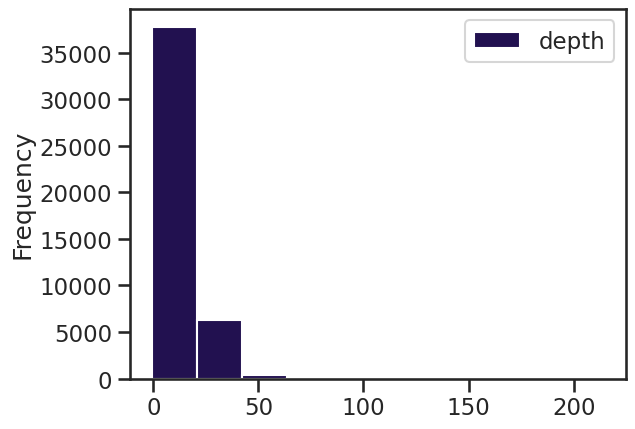

In [25]:
# histogram for continuous variables using pandas built-in plots
earthquake.plot.hist(column='depth')

<Axes: xlabel='depth', ylabel='Probability'>

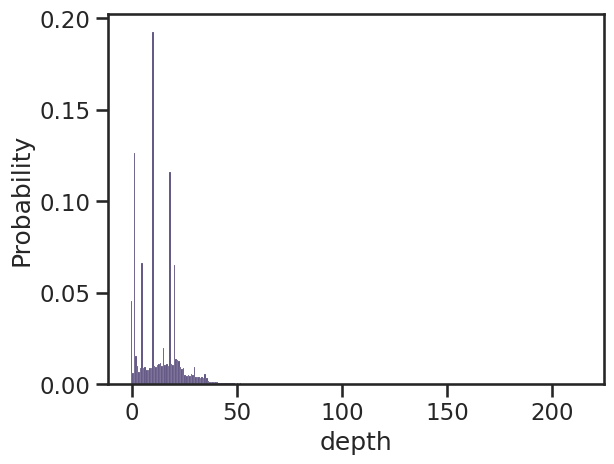

In [29]:
# relative frequency? ...
sns.histplot(x='depth', data=earthquake, stat='probability')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


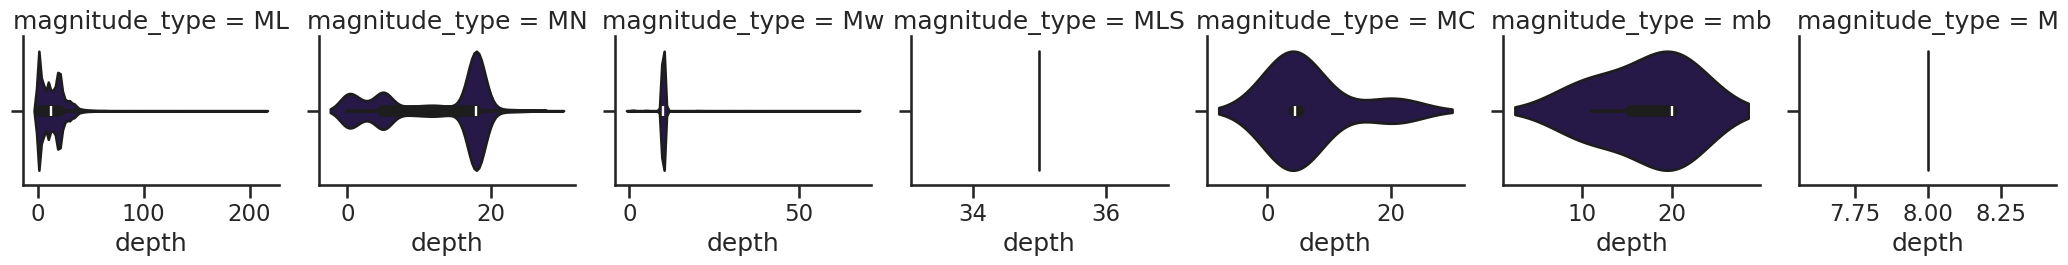

In [27]:
#histogram of masses by group
earthquake.info()
g = sns.FacetGrid(earthquake, col='magnitude_type', sharex=False)
g.map(sns.violinplot, 'depth')


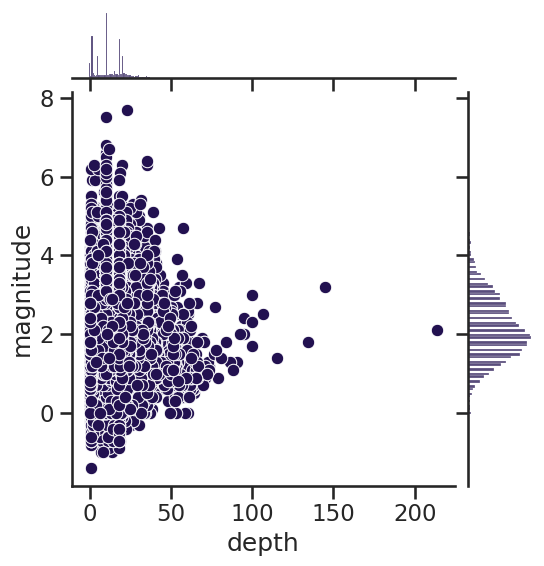

In [30]:
sns.jointplot(x='depth', y='magnitude', data=earthquake)

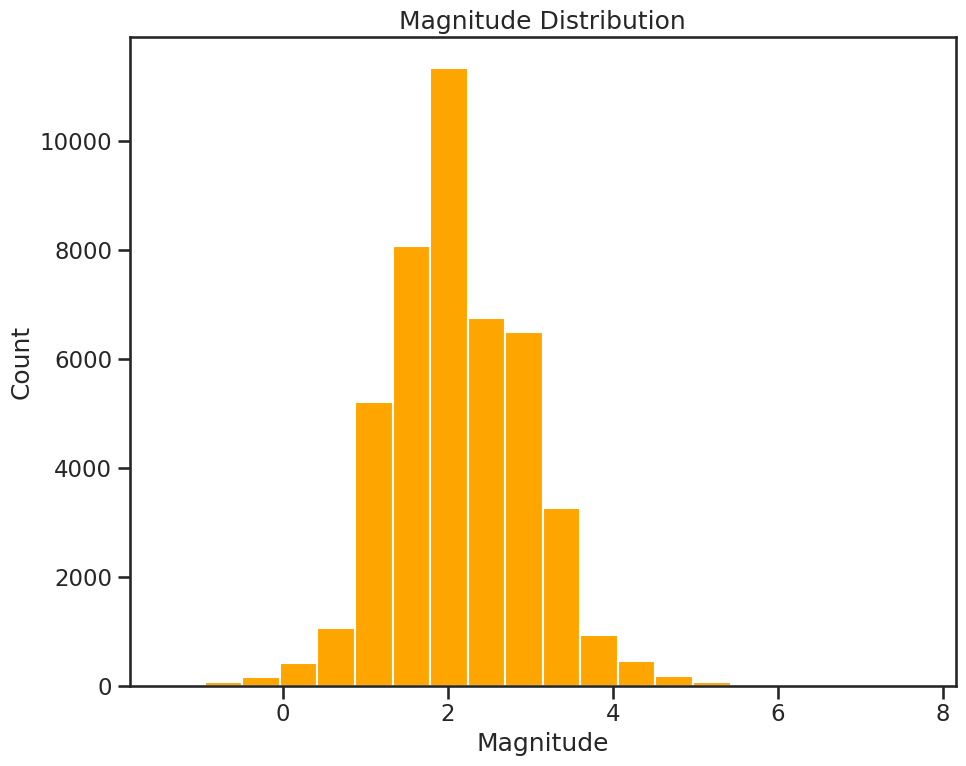

In [43]:
#first plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(earthquake['magnitude'], bins=20, color='orange')
ax.set_title('Magnitude Distribution')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

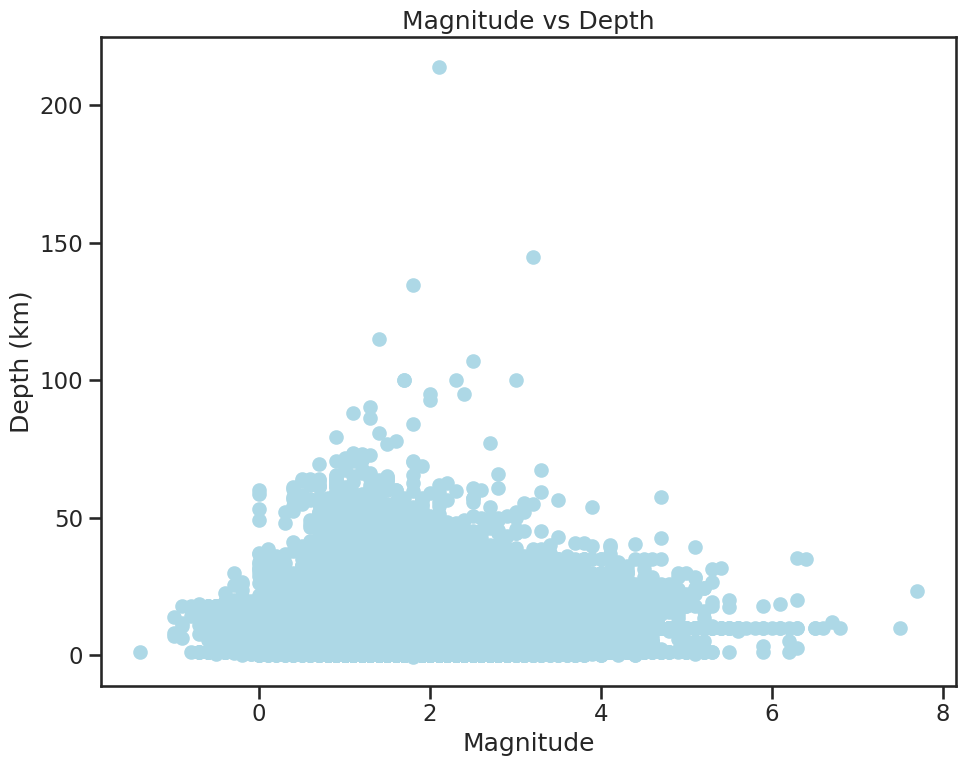

In [42]:
#second plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(earthquake['magnitude'], earthquake['depth'], color='lightblue')
ax.set_title('Magnitude vs Depth')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Depth (km)')

plt.tight_layout()
plt.show()